# Mark 4 — Two-Stage ROI Validation Smoke Test

## tl;dr

Mark 3 proved that the frozen predicted-liver ROI is geometrically safe and that the
broad one-channel representation can overfit a stratified 16-slice cohort. Mark 4 now
performs a bounded five-epoch smoke test on all training and validation patients.

The tumor model is freshly warm-started from the frozen epoch-8 multi-task checkpoint.
The 16-slice memorization checkpoint is not used. Predictions are mapped from ROI space
back to full 256×256 coordinates before every reported metric.

This notebook does not access the test split and cannot authorize test evaluation.

## Context & Methods

### Frozen pipeline

- ROI liver threshold: `0.50`.
- ROI component: largest 3D component.
- ROI padding: `16`.
- Input: broad abdominal window `[-160,240]`.
- ROI tensor: `1×256×256`.
- Tumor threshold: `0.50`.
- Loss: stable Focal-Dice.
- Maximum smoke length: `5` epochs.

### Key assumptions

- Training ROIs come from the frozen Mark 3 ROI manifest.
- Validation ROIs reproduce the selected Mark 2 global rule.
- Ground-truth tumor masks supervise training and score predictions; they do not create ROIs.
- Validation has no random augmentation.
- All patient, slice, and size metrics are calculated after inverse mapping.
- The test split remains locked.

### Temporary continuation gate

Passing permits a longer validation run, not test access:

- mean positive-patient Dice ≥0.3329;
- V104 Dice ≥0.05;
- V116 Dice ≥0.01;
- Q1 detection ≥35%;
- positive predicted-empty ≤35%;
- empty-slice false positives ≤20%;
- finite loss/gradients and no geometry failures.

In [1]:
from __future__ import annotations

from collections import OrderedDict
from pathlib import Path
from IPython.display import display
import hashlib
import json
import random
import subprocess
import sys
import time
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver")
DATASET_ROOT = Path(
    r"D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging"
    r"\build_corrected_20260713_214847_v2"
)
MANIFEST_PATH = DATASET_ROOT / "manifests" / "slice_manifest.csv"
SOURCE_CHECKPOINT = (
    PROJECT_ROOT / "Practice" / "multitask_liver_tumor_outputs" / "multitask_best.pth"
)
MARK3_DIR = PROJECT_ROOT / "mark 1" / "mark_3_outputs"
MARK3_GATE_PATH = MARK3_DIR / "mark_3_gate_result.json"
TRAIN_ROI_PATH = MARK3_DIR / "training_roi_manifest.csv"
MARK2_ROI_PATIENT_PATH = (
    PROJECT_ROOT / "mark 1" / "mark_2_outputs" / "roi_patient_results.csv"
)
OUTPUT_DIR = PROJECT_ROOT / "mark 1" / "mark_4_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

EXPECTED_MANIFEST_SHA256 = (
    "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
)
EXPECTED_SOURCE_CHECKPOINT_SHA256 = (
    "9c4160bbd68891f9dc4e5f04ceca4391f38c5869b3f81c72b95d4639e0572223"
)
SEED = 42
ROI_THRESHOLD = 0.50
ROI_PADDING = 16
ROI_COMPONENT_MODE = "largest_3d"
ROI_SIZE = 256
BROAD_WINDOW = (-160.0, 240.0)
EPOCHS = 5
BATCH_SIZE = 4
VALIDATION_BATCH_SIZE = 8
NUM_WORKERS = 0
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-5
MIN_LEARNING_RATE = 3e-5
POSITIVE_SAMPLE_WEIGHT = 3.0
TUMOR_THRESHOLD = 0.50
GRADIENT_CLIP_NORM = 5.0
MAX_START_GPU_TEMP_C = 84
EMERGENCY_STOP_TEMP_C = 90
COOLDOWN_POLL_SECONDS = 30
MAX_COOLDOWN_MINUTES = 30
RUN_TRAINING = True
RESUME_IF_AVAILABLE = True

CONTINUATION_TARGETS = {
    "mean_patient_dice": 0.3329,
    "volume_104_dice": 0.05,
    "volume_116_dice": 0.01,
    "q1_detected_pct": 35.0,
    "positive_predicted_empty_pct": 35.0,
    "empty_slice_false_positive_pct": 20.0,
}
FINAL_TARGETS = {
    "mean_patient_dice": 0.406915,
    "volume_104_dice": 0.50,
    "volume_116_dice": 0.05,
    "q1_detected_pct": 45.0,
    "positive_predicted_empty_pct": 20.0,
    "empty_slice_false_positive_pct": 15.0,
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")
print(f"Outputs: {OUTPUT_DIR}")

Device: cuda
Outputs: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\mark 1\mark_4_outputs


## Data

### 1. Verify provenance, Mark 3 authorization, and test lock

In [2]:
from src.framework.data.manifest_dataset import VerifiedManifestDataset
from src.framework.losses.focal_dice import FocalDiceLoss
from src.framework.models.mobilenetv2_unet import MobileNetV2UNet

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()

assert sha256_file(MANIFEST_PATH) == EXPECTED_MANIFEST_SHA256
assert sha256_file(SOURCE_CHECKPOINT) == EXPECTED_SOURCE_CHECKPOINT_SHA256
mark3_gate = json.loads(MARK3_GATE_PATH.read_text())
assert mark3_gate["status"] == "mark_3_overfit_pass"
assert mark3_gate["selected_configuration"]["configuration"] == "broad_1ch"
assert mark3_gate["test_images_accessed"] is False

manifest = pd.read_csv(MANIFEST_PATH)
train_manifest = (
    manifest.loc[manifest["split"].eq("train")]
    .sort_values(["volume_id", "slice_index"]).reset_index(drop=True)
)
validation_manifest = (
    manifest.loc[manifest["split"].eq("val")]
    .sort_values(["volume_id", "slice_index"]).reset_index(drop=True)
)
assert len(train_manifest) == 40_667
assert len(validation_manifest) == 10_685
try:
    VerifiedManifestDataset(MANIFEST_PATH, split="test", root_dir=DATASET_ROOT)
except PermissionError:
    pass
else:
    raise AssertionError("STOP: test split opened without authorization.")

provenance = {
    "manifest_sha256": EXPECTED_MANIFEST_SHA256,
    "source_checkpoint_sha256": EXPECTED_SOURCE_CHECKPOINT_SHA256,
    "mark3_gate_path": str(MARK3_GATE_PATH),
    "train_slices": int(len(train_manifest)),
    "validation_slices": int(len(validation_manifest)),
    "roi_rule": {
        "liver_threshold": ROI_THRESHOLD,
        "padding": ROI_PADDING,
        "component_mode": ROI_COMPONENT_MODE,
    },
    "input_window_hu": list(BROAD_WINDOW),
    "overfit_checkpoint_used_for_initialization": False,
    "test_images_accessed": False,
}
(OUTPUT_DIR / "mark_4_provenance.json").write_text(
    json.dumps(provenance, indent=2), encoding="utf-8"
)
print("PASS: provenance, Mark 3 authorization, and test lock verified.")

PASS: provenance, Mark 3 authorization, and test lock verified.


### 2. Freeze training and validation ROI manifests

In [3]:
training_rois = pd.read_csv(TRAIN_ROI_PATH)
assert len(training_rois) == 104
assert not training_rois["roi_empty"].astype(bool).any()

mark2_roi_rows = pd.read_csv(MARK2_ROI_PATIENT_PATH)
validation_rois = mark2_roi_rows.loc[
    mark2_roi_rows["liver_threshold"].eq(ROI_THRESHOLD)
    & mark2_roi_rows["padding"].eq(ROI_PADDING)
    & mark2_roi_rows["component_mode"].eq(ROI_COMPONENT_MODE)
].copy()
assert len(validation_rois) == 13
assert not validation_rois["roi_empty"].astype(bool).any()
validation_roi_path = OUTPUT_DIR / "validation_roi_manifest.csv"
validation_rois.to_csv(validation_roi_path, index=False)

roi_summary = pd.DataFrame([
    {
        "split": "train",
        "patients": len(training_rois),
        "median_area": training_rois["crop_area_ratio"].median(),
        "max_area": training_rois["crop_area_ratio"].max(),
        "empty_rois": int(training_rois["roi_empty"].sum()),
    },
    {
        "split": "validation",
        "patients": len(validation_rois),
        "median_area": validation_rois["crop_area_ratio"].median(),
        "max_area": validation_rois["crop_area_ratio"].max(),
        "empty_rois": int(validation_rois["roi_empty"].sum()),
    },
])
display(roi_summary)

,split,patients,median_area,max_area,empty_rois
0,train,104,0.420425,0.606201,0
1,validation,13,0.427002,0.533203,0


### 3. Build the ROI dataset

The existing derived PNG is the versioned `[-160,240]` broad window stored by the corrected
build. A parity audit below compares it with direct source-HU regeneration. Crops and masks
are resized using bilinear and nearest-neighbour interpolation respectively.

In [4]:
def resize_float(array, size=(ROI_SIZE, ROI_SIZE)):
    return np.asarray(
        Image.fromarray(array.astype(np.float32), mode="F").resize(
            size, Image.Resampling.BILINEAR
        ),
        dtype=np.float32,
    )

def resize_mask(array, size=(ROI_SIZE, ROI_SIZE)):
    return np.asarray(
        Image.fromarray(array.astype(np.uint8) * 255).resize(
            size, Image.Resampling.NEAREST
        ),
        dtype=np.uint8,
    ) > 0

class SynchronizedROIAugment:
    def __call__(self, image, mask):
        if random.random() < 0.30:
            image = np.fliplr(image).copy()
            mask = np.fliplr(mask).copy()
        if random.random() < 0.50:
            height, width = image.shape
            matrix = cv2.getRotationMatrix2D(
                (width / 2, height / 2),
                random.uniform(-8, 8),
                random.uniform(0.97, 1.03),
            )
            image = cv2.warpAffine(
                image, matrix, (width, height), flags=cv2.INTER_LINEAR
            )
            mask = cv2.warpAffine(
                mask.astype(np.uint8), matrix, (width, height),
                flags=cv2.INTER_NEAREST,
            ) > 0
        if random.random() < 0.35:
            image = np.clip(
                image + np.random.normal(0, 0.015, image.shape), 0, 1
            )
        return image.astype(np.float32), mask.astype(np.float32)

class ROISliceDataset(Dataset):
    def __init__(self, rows, roi_frame, augment=None):
        self.rows = rows.reset_index(drop=True)
        self.rois = roi_frame.set_index("volume_id")
        self.augment = augment

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows.iloc[index]
        box = self.rois.loc[int(row.volume_id)]
        y0, y1, x0, x1 = [
            int(box[key]) for key in ("y0", "y1", "x0", "x1")
        ]
        with Image.open(DATASET_ROOT / row.image_path) as handle:
            image = np.asarray(handle.convert("L"), dtype=np.float32) / 255.0
        with Image.open(DATASET_ROOT / row.tumor_mask_path) as handle:
            truth_full = np.asarray(handle.convert("L"), dtype=np.uint8) > 0
        image_roi = resize_float(image[y0:y1, x0:x1])
        truth_roi = resize_mask(truth_full[y0:y1, x0:x1])
        if self.augment is not None:
            image_roi, truth_roi = self.augment(image_roi, truth_roi)
        return {
            "image": torch.from_numpy(image_roi[None]).float(),
            "mask": torch.from_numpy(np.asarray(truth_roi)[None]).float(),
            "sample_id": str(row.sample_id),
            "volume_id": int(row.volume_id),
            "slice_index": int(row.slice_index),
            "true_pixels_full": int(row.tumor_pixels),
            "box": torch.tensor([y0, y1, x0, x1], dtype=torch.int32),
        }

train_dataset = ROISliceDataset(
    train_manifest, training_rois, augment=SynchronizedROIAugment()
)
validation_dataset = ROISliceDataset(
    validation_manifest, validation_rois, augment=None
)
print(f"Train={len(train_dataset):,} | Validation={len(validation_dataset):,}")

Train=40,667 | Validation=10,685


### 4. Audit PNG/source-HU parity and crop geometry

       mean_absolute_error  max_absolute_error
count            32.000000           32.000000
mean              0.000529            0.004485
std               0.000124            0.000149
min               0.000283            0.004277
25%               0.000443            0.004367
50%               0.000539            0.004465
75%               0.000599            0.004581
max               0.000744            0.004874


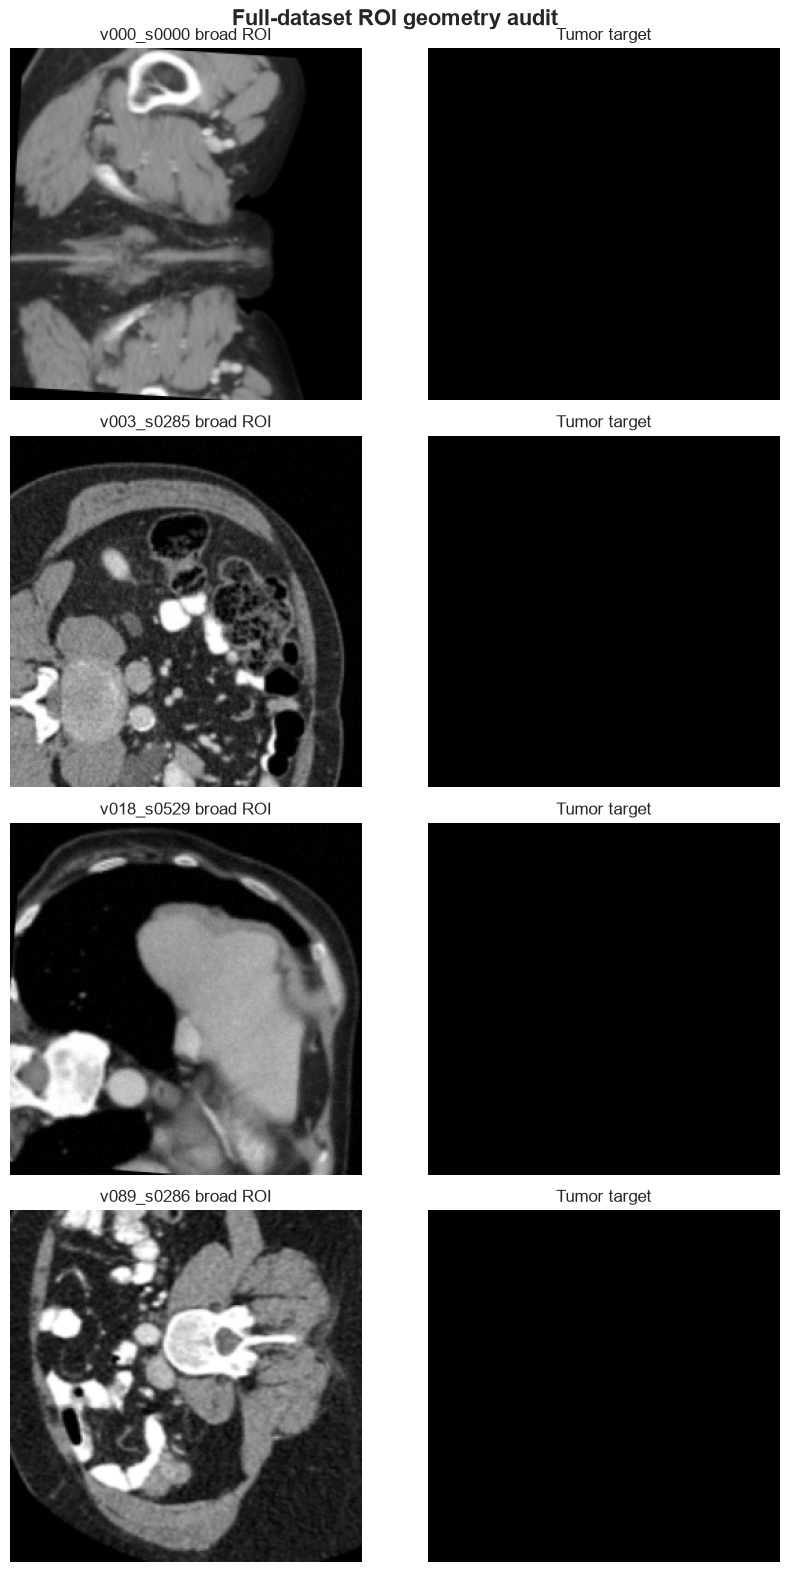

In [5]:
import nibabel as nib

audit_rows = train_manifest.sample(32, random_state=SEED)
parity_rows = []
loaded_volumes = {}
for row in audit_rows.itertuples(index=False):
    if row.source_volume_path not in loaded_volumes:
        loaded_volumes[row.source_volume_path] = nib.load(str(row.source_volume_path))
    hu = np.asanyarray(
        loaded_volumes[row.source_volume_path].dataobj[:, :, int(row.slice_index)]
    ).astype(np.float32)
    regenerated = np.clip(
        (hu - BROAD_WINDOW[0]) / (BROAD_WINDOW[1] - BROAD_WINDOW[0]), 0, 1
    )
    regenerated = resize_float(regenerated)
    with Image.open(DATASET_ROOT / row.image_path) as handle:
        stored = np.asarray(handle.convert("L"), dtype=np.float32) / 255.0
    parity_rows.append({
        "sample_id": row.sample_id,
        "mean_absolute_error": float(np.mean(np.abs(regenerated - stored))),
        "max_absolute_error": float(np.max(np.abs(regenerated - stored))),
    })
parity = pd.DataFrame(parity_rows)
parity.to_csv(OUTPUT_DIR / "broad_png_source_parity.csv", index=False)
print(parity.describe())
assert parity["mean_absolute_error"].median() <= 0.01

preview = [train_dataset[index] for index in [0, 1000, 10000, 30000]]
figure, axes = plt.subplots(4, 2, figsize=(9, 16))
for row_axes, item in zip(axes, preview):
    row_axes[0].imshow(item["image"][0], cmap="gray", vmin=0, vmax=1)
    row_axes[0].set_title(f"{item['sample_id']} broad ROI")
    row_axes[1].imshow(item["mask"][0], cmap="gray", vmin=0, vmax=1)
    row_axes[1].set_title("Tumor target")
    for axis in row_axes:
        axis.axis("off")
figure.suptitle("Full-dataset ROI geometry audit", fontsize=16, weight="bold")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "roi_dataset_audit.png", dpi=170, bbox_inches="tight")
plt.show()

### 5. Build patient-aware stratified loaders

In [6]:
volume_counts = train_manifest["volume_id"].value_counts()
weights = train_manifest["volume_id"].map(
    lambda volume_id: 1.0 / volume_counts.loc[volume_id]
).to_numpy(dtype=np.float64)
weights *= np.where(
    train_manifest["tumor_pixels"].to_numpy() > 0,
    POSITIVE_SAMPLE_WEIGHT,
    1.0,
)
weights /= weights.mean()
sampler_generator = torch.Generator().manual_seed(SEED)
sampler = WeightedRandomSampler(
    torch.as_tensor(weights, dtype=torch.double),
    num_samples=len(train_dataset),
    replacement=True,
    generator=sampler_generator,
)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)
validation_loader = DataLoader(
    validation_dataset, batch_size=VALIDATION_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)
sampling_summary = pd.DataFrame([
    {
        "stratum": "tumor_positive",
        "rows": int(train_manifest["tumor_pixels"].gt(0).sum()),
        "multiplier": POSITIVE_SAMPLE_WEIGHT,
    },
    {
        "stratum": "tumor_negative",
        "rows": int(train_manifest["tumor_pixels"].eq(0).sum()),
        "multiplier": 1.0,
    },
])
display(sampling_summary)

,stratum,rows,multiplier
0,tumor_positive,4930,3.0
1,tumor_negative,35737,1.0


## Training

### 6. Freshly warm-start the one-channel tumor model

In [7]:
source_payload = torch.load(SOURCE_CHECKPOINT, map_location="cpu", weights_only=False)
source_state = source_payload["model_state"]
model = MobileNetV2UNet(in_channels=1, out_channels=1, pretrained=False)
target_state = model.state_dict()
for key, value in source_state.items():
    if key in target_state and target_state[key].shape == value.shape:
        target_state[key] = value.clone()
target_state["final.weight"] = source_state["final.weight"][1:2].clone()
target_state["final.bias"] = source_state["final.bias"][1:2].clone()
model.load_state_dict(target_state, strict=True)
model.to(device)

loss_function = FocalDiceLoss(
    focal_alpha=0.75, focal_gamma=2.0, focal_weight=0.5, dice_weight=0.5
)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=MIN_LEARNING_RATE
)
print("PASS: fresh warm start from epoch-8 multi-task checkpoint.")

PASS: fresh warm start from epoch-8 multi-task checkpoint.


### 7. Define full-image validation metrics

In [8]:
def probability_to_full(probability_roi, box):
    y0, y1, x0, x1 = [int(value) for value in box]
    resized = np.asarray(
        Image.fromarray(probability_roi.astype(np.float32), mode="F").resize(
            (x1 - x0, y1 - y0), Image.Resampling.BILINEAR
        ),
        dtype=np.float32,
    )
    full = np.zeros((256, 256), dtype=np.float32)
    full[y0:y1, x0:x1] = resized
    return full

def evaluate(model):
    model.eval()
    patient_accumulators = {}
    slice_rows = []
    validation_loss = 0.0
    with torch.inference_mode():
        for batch in validation_loader:
            images = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True)
            logits = model(images)
            loss = loss_function(logits, masks)
            validation_loss += float(loss) * len(images)
            probabilities = torch.sigmoid(logits).cpu().numpy()[:, 0]
            for index, sample_id in enumerate(batch["sample_id"]):
                volume_id = int(batch["volume_id"][index])
                slice_index = int(batch["slice_index"][index])
                box = batch["box"][index].numpy()
                probability_full = probability_to_full(
                    probabilities[index], box
                )
                prediction = probability_full >= TUMOR_THRESHOLD
                manifest_row = validation_manifest.loc[
                    validation_manifest["sample_id"].eq(sample_id)
                ].iloc[0]
                with Image.open(
                    DATASET_ROOT / manifest_row["tumor_mask_path"]
                ) as handle:
                    truth = np.asarray(handle.convert("L"), dtype=np.uint8) > 0
                intersection = int((prediction & truth).sum())
                predicted = int(prediction.sum())
                true = int(truth.sum())
                values = patient_accumulators.setdefault(
                    volume_id,
                    {
                        "intersection": 0, "predicted": 0, "true": 0,
                        "positive": 0, "detected": 0, "positive_empty": 0,
                        "empty": 0, "empty_fp": 0,
                    },
                )
                values["intersection"] += intersection
                values["predicted"] += predicted
                values["true"] += true
                if true > 0:
                    values["positive"] += 1
                    values["detected"] += int(intersection > 0)
                    values["positive_empty"] += int(predicted == 0)
                else:
                    values["empty"] += 1
                    values["empty_fp"] += int(predicted > 0)
                slice_rows.append({
                    "sample_id": sample_id,
                    "volume_id": volume_id,
                    "slice_index": slice_index,
                    "true_pixels": true,
                    "predicted_pixels": predicted,
                    "intersection_pixels": intersection,
                    "dice": (2 * intersection + 1e-6)
                    / (predicted + true + 1e-6),
                })

    patient_rows = []
    for volume_id, values in sorted(patient_accumulators.items()):
        patient_rows.append({
            "volume_id": volume_id,
            "true_pixels": values["true"],
            "predicted_pixels": values["predicted"],
            "micro_dice": (
                (2 * values["intersection"] + 1e-6)
                / (values["predicted"] + values["true"] + 1e-6)
            ),
            "positive_predicted_empty_pct": (
                100 * values["positive_empty"] / max(values["positive"], 1)
            ),
            "empty_slice_false_positive_pct": (
                100 * values["empty_fp"] / max(values["empty"], 1)
            ),
        })
    patients = pd.DataFrame(patient_rows)
    slices = pd.DataFrame(slice_rows)
    positive_patients = patients.loc[patients["true_pixels"].gt(0)]
    positive_slices = slices.loc[slices["true_pixels"].gt(0)].copy()
    positive_slices["size_quartile"] = pd.qcut(
        positive_slices["true_pixels"], 4,
        labels=["Q1", "Q2", "Q3", "Q4"],
    )
    size_rows = []
    for quartile, group in positive_slices.groupby(
        "size_quartile", observed=True
    ):
        size_rows.append({
            "size_quartile": str(quartile),
            "slices": len(group),
            "mean_dice": group["dice"].mean(),
            "detected_pct": 100 * (group["intersection_pixels"] > 0).mean(),
            "predicted_empty_pct": 100 * (group["predicted_pixels"] == 0).mean(),
        })
    sizes = pd.DataFrame(size_rows)
    totals = patient_accumulators.values()
    result = {
        "validation_loss": validation_loss / len(validation_dataset),
        "mean_patient_dice": float(positive_patients["micro_dice"].mean()),
        "median_patient_dice": float(positive_patients["micro_dice"].median()),
        "worst_patient_dice": float(positive_patients["micro_dice"].min()),
        "volume_104_dice": float(
            patients.set_index("volume_id")["micro_dice"].get(104, np.nan)
        ),
        "volume_116_dice": float(
            patients.set_index("volume_id")["micro_dice"].get(116, np.nan)
        ),
        "q1_detected_pct": float(
            sizes.set_index("size_quartile").loc["Q1", "detected_pct"]
        ),
        "positive_predicted_empty_pct": float(
            100 * sum(v["positive_empty"] for v in totals)
            / max(sum(v["positive"] for v in patient_accumulators.values()), 1)
        ),
        "empty_slice_false_positive_pct": float(
            100 * sum(v["empty_fp"] for v in patient_accumulators.values())
            / max(sum(v["empty"] for v in patient_accumulators.values()), 1)
        ),
    }
    return result, patients, slices, sizes

### 8. Thermal controls and resumable epoch checkpoints

In [9]:
def gpu_temperature():
    if not torch.cuda.is_available():
        return np.nan
    try:
        result = subprocess.run(
            [
                "nvidia-smi", "--query-gpu=temperature.gpu",
                "--format=csv,noheader,nounits",
            ],
            capture_output=True, text=True, check=True,
        )
        return float(result.stdout.splitlines()[0])
    except Exception:
        return np.nan

def wait_for_cooldown(epoch):
    started = time.time()
    while True:
        temperature = gpu_temperature()
        if not np.isfinite(temperature) or temperature < MAX_START_GPU_TEMP_C:
            return temperature
        if temperature >= EMERGENCY_STOP_TEMP_C:
            raise RuntimeError(
                f"GPU reached emergency temperature {temperature:.0f}C."
            )
        if time.time() - started >= MAX_COOLDOWN_MINUTES * 60:
            raise RuntimeError("GPU cooldown timed out.")
        print(f"Cooling before epoch {epoch}: {temperature:.0f}C")
        time.sleep(COOLDOWN_POLL_SECONDS)

def freeze_batchnorm_running_stats(model):
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()

history = []
start_epoch = 1
last_path = OUTPUT_DIR / "mark_4_last.pth"
if RESUME_IF_AVAILABLE and last_path.is_file():
    resume = torch.load(last_path, map_location="cpu", weights_only=False)
    assert resume["manifest_sha256"] == EXPECTED_MANIFEST_SHA256
    assert resume["source_checkpoint_sha256"] == EXPECTED_SOURCE_CHECKPOINT_SHA256
    model.load_state_dict(resume["model_state"], strict=True)
    optimizer.load_state_dict(resume["optimizer_state"])
    scheduler.load_state_dict(resume["scheduler_state"])
    history = resume["history"]
    start_epoch = int(resume["epoch"]) + 1
    print(f"Resuming at epoch {start_epoch}.")

### 9. Run the bounded five-epoch smoke test

In [10]:
best_score = -np.inf
best_epoch = None
best_result = None

if RUN_TRAINING:
    for epoch in range(start_epoch, EPOCHS + 1):
        start_temperature = wait_for_cooldown(epoch)
        epoch_started = time.perf_counter()
        model.train()
        freeze_batchnorm_running_stats(model)
        train_loss = 0.0
        gradients_finite = True
        for batch in train_loader:
            images = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = loss_function(logits, masks)
            if not torch.isfinite(loss):
                raise FloatingPointError("Non-finite training loss.")
            loss.backward()
            gradients_finite &= all(
                parameter.grad is None or torch.isfinite(parameter.grad).all()
                for parameter in model.parameters()
            )
            if not gradients_finite:
                raise FloatingPointError("Non-finite gradient.")
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), GRADIENT_CLIP_NORM
            )
            optimizer.step()
            train_loss += float(loss) * len(images)

        result, patient_metrics, slice_metrics, size_metrics = evaluate(model)
        scheduler.step()
        record = {
            "epoch": epoch,
            "train_loss": train_loss / len(train_dataset),
            **result,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "start_temperature_c": start_temperature,
            "end_temperature_c": gpu_temperature(),
            "elapsed_seconds": time.perf_counter() - epoch_started,
            "gradients_finite": gradients_finite,
        }
        history.append(record)
        history_frame = pd.DataFrame(history)
        history_frame.to_csv(OUTPUT_DIR / "mark_4_history.csv", index=False)

        payload = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "history": history,
            "manifest_sha256": EXPECTED_MANIFEST_SHA256,
            "source_checkpoint_sha256": EXPECTED_SOURCE_CHECKPOINT_SHA256,
            "roi_rule": provenance["roi_rule"],
            "input_window_hu": list(BROAD_WINDOW),
        }
        torch.save(payload, last_path)

        if result["mean_patient_dice"] > best_score:
            best_score = result["mean_patient_dice"]
            best_epoch = epoch
            best_result = result
            torch.save(payload, OUTPUT_DIR / "mark_4_best.pth")
            patient_metrics.to_csv(
                OUTPUT_DIR / "best_validation_patient_metrics.csv", index=False
            )
            slice_metrics.to_csv(
                OUTPUT_DIR / "best_validation_per_slice.csv", index=False
            )
            size_metrics.to_csv(
                OUTPUT_DIR / "best_validation_size_metrics.csv", index=False
            )

        print(
            f"epoch={epoch} train={record['train_loss']:.4f} "
            f"val={record['validation_loss']:.4f} "
            f"patient={record['mean_patient_dice']:.4f} "
            f"V104={record['volume_104_dice']:.4f} "
            f"V116={record['volume_116_dice']:.4f} "
            f"Q1={record['q1_detected_pct']:.1f}% "
            f"emptyFP={record['empty_slice_false_positive_pct']:.1f}%"
        )

history_frame = pd.DataFrame(history)
display(history_frame)

C:\Users\alanm\AppData\Local\Temp\ipykernel_17540\1947750583.py:66: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  "image": torch.from_numpy(image_roi[None]).float(),


epoch=1 train=0.1301 val=0.0569 patient=0.2978 V104=0.0019 V116=0.0049 Q1=21.3% emptyFP=1.0%
Cooling before epoch 2: 86C
epoch=2 train=0.1024 val=0.0627 patient=0.3090 V104=0.0035 V116=0.0034 Q1=40.3% emptyFP=3.3%
Cooling before epoch 3: 84C
epoch=3 train=0.0871 val=0.0684 patient=0.3056 V104=0.0088 V116=0.0049 Q1=47.5% emptyFP=4.7%
Cooling before epoch 4: 85C
epoch=4 train=0.0707 val=0.0576 patient=0.3549 V104=0.0101 V116=0.0352 Q1=41.1% emptyFP=2.5%
Cooling before epoch 5: 86C
epoch=5 train=0.0610 val=0.0607 patient=0.3639 V104=0.0672 V116=0.0108 Q1=42.6% emptyFP=3.4%


,epoch,train_loss,validation_loss,mean_patient_dice,median_patient_dice,worst_patient_dice,volume_104_dice,volume_116_dice,q1_detected_pct,positive_predicted_empty_pct,empty_slice_false_positive_pct,learning_rate,start_temperature_c,end_temperature_c,elapsed_seconds,gradients_finite
0,1,0.130088,0.056866,0.297799,0.246682,0.001938,0.001938,0.004926,21.292776,50.287908,0.954060,0.000274,68.0,84.0,1068.012946,True
1,2,0.102449,0.062709,0.309006,0.210320,0.003376,0.003525,0.003376,40.304183,39.827255,3.318469,0.000207,74.0,86.0,1058.124801,True
2,3,0.087086,0.068398,0.305599,0.158734,0.004894,0.008801,0.004894,47.528517,33.397313,4.666598,0.000123,73.0,87.0,1045.736382,True
3,4,0.070738,0.057609,0.354879,0.320160,0.010146,0.010146,0.035249,41.064639,39.155470,2.530333,0.000056,74.0,85.0,1067.490074,True
4,5,0.060989,0.060651,0.363866,0.414723,0.010780,0.067187,0.010780,42.585551,36.852207,3.422172,0.000030,74.0,86.0,1037.105877,True


## Results

### 10. Visualize smoke-test trajectories

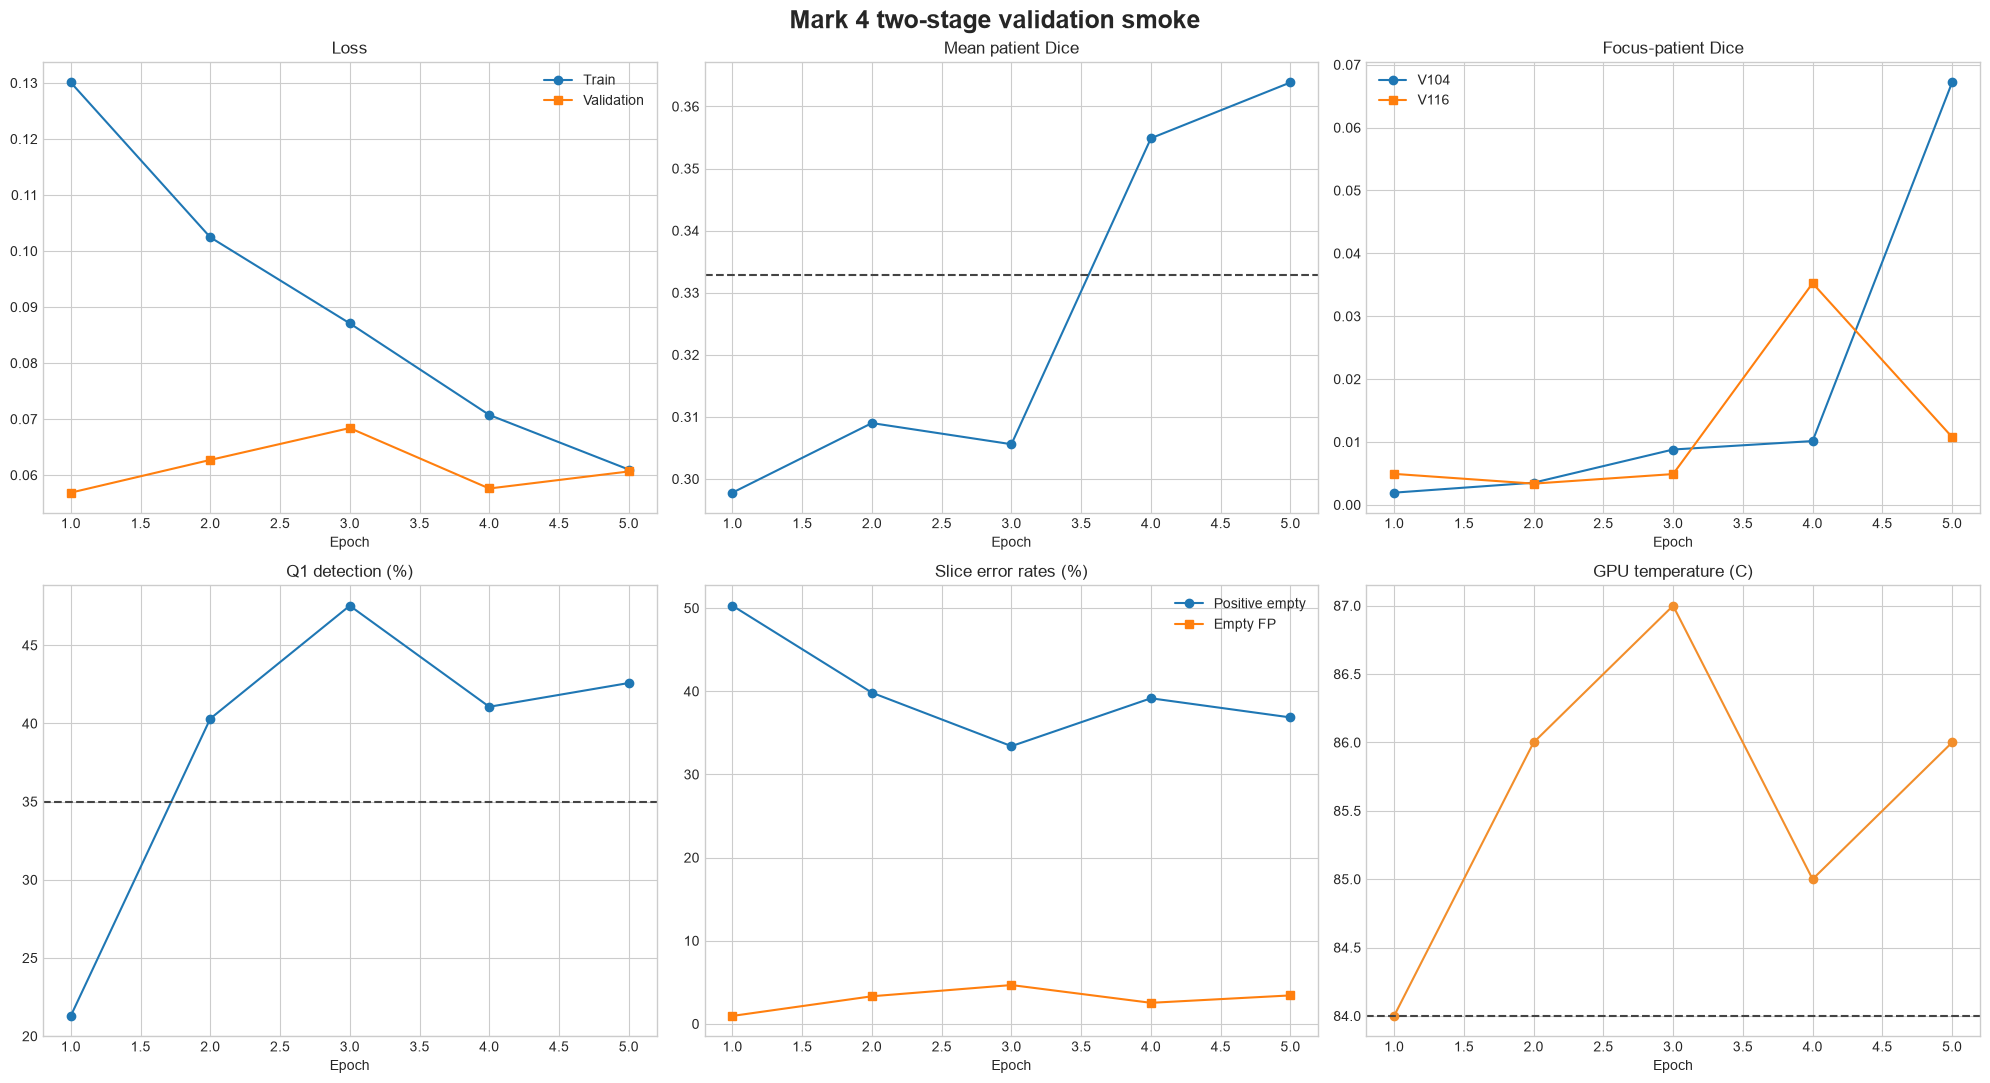

In [11]:
figure, axes = plt.subplots(2, 3, figsize=(20, 11))
axes[0, 0].plot(history_frame["epoch"], history_frame["train_loss"],
                marker="o", label="Train")
axes[0, 0].plot(history_frame["epoch"], history_frame["validation_loss"],
                marker="s", label="Validation")
axes[0, 0].set_title("Loss"); axes[0, 0].legend()
axes[0, 1].plot(history_frame["epoch"], history_frame["mean_patient_dice"],
                marker="o")
axes[0, 1].axhline(
    CONTINUATION_TARGETS["mean_patient_dice"], linestyle="--", color="#444"
)
axes[0, 1].set_title("Mean patient Dice")
axes[0, 2].plot(history_frame["epoch"], history_frame["volume_104_dice"],
                marker="o", label="V104")
axes[0, 2].plot(history_frame["epoch"], history_frame["volume_116_dice"],
                marker="s", label="V116")
axes[0, 2].legend(); axes[0, 2].set_title("Focus-patient Dice")
axes[1, 0].plot(history_frame["epoch"], history_frame["q1_detected_pct"],
                marker="o")
axes[1, 0].axhline(
    CONTINUATION_TARGETS["q1_detected_pct"], linestyle="--", color="#444"
)
axes[1, 0].set_title("Q1 detection (%)")
axes[1, 1].plot(
    history_frame["epoch"],
    history_frame["positive_predicted_empty_pct"],
    marker="o", label="Positive empty",
)
axes[1, 1].plot(
    history_frame["epoch"],
    history_frame["empty_slice_false_positive_pct"],
    marker="s", label="Empty FP",
)
axes[1, 1].legend(); axes[1, 1].set_title("Slice error rates (%)")
axes[1, 2].plot(
    history_frame["epoch"], history_frame["end_temperature_c"],
    marker="o", color="#F28E2B",
)
axes[1, 2].axhline(MAX_START_GPU_TEMP_C, linestyle="--", color="#444")
axes[1, 2].set_title("GPU temperature (C)")
for axis in axes.flat:
    axis.set_xlabel("Epoch")
figure.suptitle("Mark 4 two-stage validation smoke", fontsize=18, weight="bold")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "mark_4_smoke_dashboard.png",
               dpi=170, bbox_inches="tight")
plt.show()

### 11. Inspect best full-image predictions

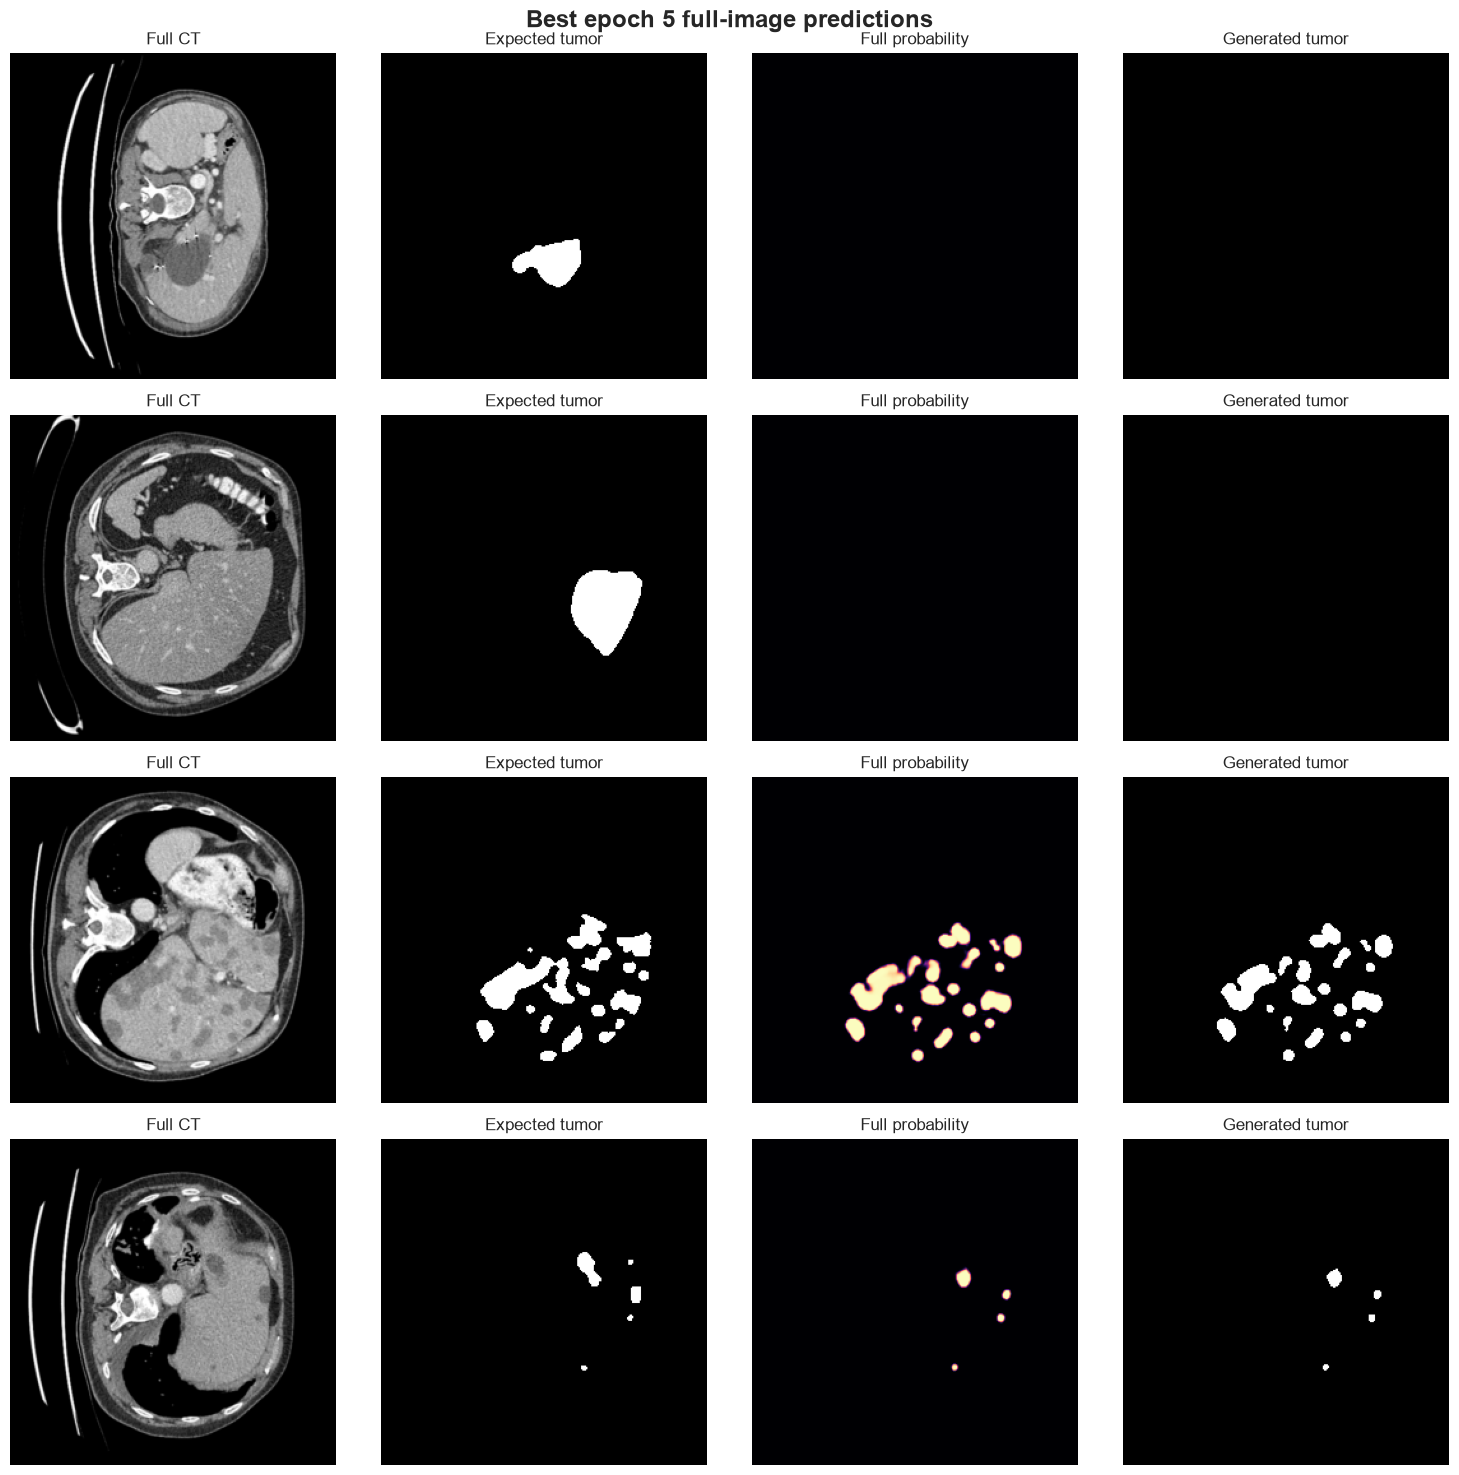

In [12]:
best_payload = torch.load(
    OUTPUT_DIR / "mark_4_best.pth", map_location=device, weights_only=False
)
model.load_state_dict(best_payload["model_state"], strict=True)
model.eval()
focus_rows = []
for volume_id in [104, 116, 108, 109]:
    candidates = validation_manifest.loc[
        validation_manifest["volume_id"].eq(volume_id)
        & validation_manifest["tumor_pixels"].gt(0)
    ]
    focus_rows.append(candidates.nlargest(1, "tumor_pixels").iloc[0])

figure, axes = plt.subplots(4, 4, figsize=(15, 15))
for row_axes, row in zip(axes, focus_rows):
    dataset_index = int(
        validation_manifest.index[
            validation_manifest["sample_id"].eq(row.sample_id)
        ][0]
    )
    item = validation_dataset[dataset_index]
    with torch.inference_mode():
        probability_roi = torch.sigmoid(
            model(item["image"][None].to(device))
        )[0, 0].cpu().numpy()
    probability_full = probability_to_full(
        probability_roi, item["box"].numpy()
    )
    prediction = probability_full >= TUMOR_THRESHOLD
    with Image.open(DATASET_ROOT / row.image_path) as handle:
        image = np.asarray(handle.convert("L"), dtype=np.float32) / 255.0
    with Image.open(DATASET_ROOT / row.tumor_mask_path) as handle:
        truth = np.asarray(handle.convert("L"), dtype=np.uint8) > 0
    panels = [
        (image, "Full CT"),
        (truth, "Expected tumor"),
        (probability_full, "Full probability"),
        (prediction, "Generated tumor"),
    ]
    for axis, (panel, title) in zip(row_axes, panels):
        axis.imshow(panel, cmap="magma" if "probability" in title else "gray",
                    vmin=0, vmax=1)
        axis.set_title(title); axis.axis("off")
    row_axes[0].set_ylabel(f"V{int(row.volume_id)}", fontsize=10)
figure.suptitle(
    f"Best epoch {best_epoch} full-image predictions",
    fontsize=17, weight="bold",
)
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "best_full_image_predictions.png",
               dpi=170, bbox_inches="tight")
plt.show()

## Takeaways

### 12. Apply the continuation gate

In [13]:
best_record = history_frame.loc[
    history_frame["mean_patient_dice"].idxmax()
].to_dict()
passes = {
    "mean_patient_dice": (
        best_record["mean_patient_dice"]
        >= CONTINUATION_TARGETS["mean_patient_dice"]
    ),
    "volume_104_dice": (
        best_record["volume_104_dice"]
        >= CONTINUATION_TARGETS["volume_104_dice"]
    ),
    "volume_116_dice": (
        best_record["volume_116_dice"]
        >= CONTINUATION_TARGETS["volume_116_dice"]
    ),
    "q1_detected_pct": (
        best_record["q1_detected_pct"]
        >= CONTINUATION_TARGETS["q1_detected_pct"]
    ),
    "positive_predicted_empty_pct": (
        best_record["positive_predicted_empty_pct"]
        <= CONTINUATION_TARGETS["positive_predicted_empty_pct"]
    ),
    "empty_slice_false_positive_pct": (
        best_record["empty_slice_false_positive_pct"]
        <= CONTINUATION_TARGETS["empty_slice_false_positive_pct"]
    ),
    "gradients_finite": bool(best_record["gradients_finite"]),
}
continuation_passed = all(passes.values())
final_passes = {
    key: (
        best_record[key] <= target
        if key in (
            "positive_predicted_empty_pct",
            "empty_slice_false_positive_pct",
        )
        else best_record[key] >= target
    )
    for key, target in FINAL_TARGETS.items()
}
gate = {
    "status": (
        "mark_4_smoke_pass" if continuation_passed else "mark_4_smoke_fail"
    ),
    "best_epoch": int(best_record["epoch"]),
    "best_metrics": {
        key: float(best_record[key])
        for key in CONTINUATION_TARGETS
    },
    "continuation_targets": CONTINUATION_TARGETS,
    "continuation_passes": passes,
    "continuation_gate_passed": continuation_passed,
    "final_validation_targets": FINAL_TARGETS,
    "final_targets_passed": final_passes,
    "all_final_targets_passed": all(final_passes.values()),
    "manifest_sha256": EXPECTED_MANIFEST_SHA256,
    "source_checkpoint_sha256": EXPECTED_SOURCE_CHECKPOINT_SHA256,
    "overfit_checkpoint_used_for_initialization": False,
    "test_images_accessed": False,
    "decision": (
        "PROCEED_TO_BOUNDED_LONGER_TWO_STAGE_VALIDATION_RUN"
        if continuation_passed else
        "STOP_AND_DIAGNOSE_TWO_STAGE_SMOKE_FAILURE"
    ),
    "next_notebook": (
        "mark_5_two_stage_bounded_continuation"
        if continuation_passed else
        "mark_4_failure_diagnostics"
    ),
}
(OUTPUT_DIR / "mark_4_gate_result.json").write_text(
    json.dumps(gate, indent=2), encoding="utf-8"
)
expected_actual = pd.DataFrame([
    {
        "metric": key,
        "actual": best_record[key],
        "continuation_target": CONTINUATION_TARGETS[key],
        "continuation_passed": passes[key],
        "final_target": FINAL_TARGETS[key],
        "final_passed": final_passes[key],
    }
    for key in CONTINUATION_TARGETS
])
expected_actual.to_csv(
    OUTPUT_DIR / "expected_vs_actual.csv", index=False
)
display(pd.DataFrame([gate]).T.rename(columns={0: "value"}))
display(expected_actual)
print(gate["decision"])

,value
status,mark_4_smoke_fail
best_epoch,5
best_metrics,"{'mean_patient_dice': 0.3638655123989007, 'vol..."
continuation_targets,"{'mean_patient_dice': 0.3329, 'volume_104_dice..."
continuation_passes,"{'mean_patient_dice': True, 'volume_104_dice':..."
continuation_gate_passed,False
final_validation_targets,"{'mean_patient_dice': 0.406915, 'volume_104_di..."
final_targets_passed,"{'mean_patient_dice': False, 'volume_104_dice'..."
all_final_targets_passed,False
manifest_sha256,575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63...


,metric,actual,continuation_target,continuation_passed,final_target,final_passed
0,mean_patient_dice,0.363866,0.3329,True,0.406915,False
1,volume_104_dice,0.067187,0.0500,True,0.500000,False
2,volume_116_dice,0.010780,0.0100,True,0.050000,False
3,q1_detected_pct,42.585551,35.0000,True,45.000000,False
4,positive_predicted_empty_pct,36.852207,35.0000,False,20.000000,False
5,empty_slice_false_positive_pct,3.422172,20.0000,True,15.000000,True


STOP_AND_DIAGNOSE_TWO_STAGE_SMOKE_FAILURE


### Interpretation contract

- Passing authorizes only a bounded longer validation run.
- Failing requires probability, sampling, and patient-level diagnostics; do not open test.
- The temporary continuation criteria do not replace the final validation targets.
- A longer run must retain the same ROI, input representation, inverse mapping, metrics,
  patient split, and checkpoint provenance.
- The test split remains locked until one frozen configuration passes every final target.